In [1]:
import os
from pathlib import Path
import numpy as np
from tqdm import tqdm

import plotly.graph_objects as go
from Bio.PDB import PDBParser
import py3Dmol

from mdm2_breaker import ProteinFeaturizer, SmallMoleculeFeaturizer

ROOT = Path(os.getcwd()).parents[0]

In [2]:
pdb_file = os.path.join(ROOT, "data", "MDM2_Breaker", "raw", "1YCR.pdb")
mol_file = os.path.join(ROOT, "data", "MDM2_Breaker", "raw", "bindingdb_p53_binding_protein_mdm2.tsv")

## Parse the Protein

In [3]:
protein = ProteinFeaturizer(pdb_file = pdb_file)
coords, _ = protein._parse_structure()
coords.shape

(98, 3)

In [4]:
coords[None, :, :].shape

(1, 98, 3)

In [5]:
coords[:, None, :].shape

(98, 1, 3)

In [6]:
(coords[:, None, :] - coords[None, :, :])

array([[[  0.        ,   0.        ,   0.        ],
        [ -2.5320005 ,  -0.51799965,  -2.803     ],
        [ -3.7390003 ,  -4.045     ,  -2.1200001 ],
        ...,
        [ -8.318     ,   9.419001  ,  -2.242     ],
        [ -7.0150003 ,   6.8050003 ,   0.20499992],
        [ -5.023     ,   4.7649994 ,  -2.302     ]],

       [[  2.5320005 ,   0.51799965,   2.803     ],
        [  0.        ,   0.        ,   0.        ],
        [ -1.2069998 ,  -3.5270004 ,   0.68299997],
        ...,
        [ -5.7859993 ,   9.937     ,   0.561     ],
        [ -4.483     ,   7.323     ,   3.008     ],
        [ -2.4909992 ,   5.282999  ,   0.50100005]],

       [[  3.7390003 ,   4.045     ,   2.1200001 ],
        [  1.2069998 ,   3.5270004 ,  -0.68299997],
        [  0.        ,   0.        ,   0.        ],
        ...,
        [ -4.5789995 ,  13.464001  ,  -0.12199998],
        [ -3.276     ,  10.85      ,   2.325     ],
        [ -1.2839994 ,   8.809999  ,  -0.18199992]],

       ...,

      

In [7]:
import torch
distances = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)
src, dst = np.where((distances < 8) & (distances > 0))
edge_index = torch.tensor([src, dst], dtype=torch.long)
edge_index.t()


/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_10709/1513980429.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)


tensor([[ 0,  1],
        [ 0,  2],
        [ 0, 24],
        ...,
        [97, 26],
        [97, 95],
        [97, 96]])

In [8]:
(coords[:, None, :] - coords[None, :, :]).shape

(98, 98, 3)

In [9]:
np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1).shape

(98, 98)

In [10]:
coords

array([[ 11.124, -13.382,  -4.414],
       [ 13.656, -12.864,  -1.611],
       [ 14.863,  -9.337,  -2.294],
       [ 18.243,  -8.753,  -0.623],
       [ 20.65 ,  -5.812,  -0.577],
       [ 24.328,  -6.842,  -0.726],
       [ 26.812,  -5.44 ,   1.782],
       [ 29.752,  -3.21 ,   0.585],
       [ 32.37 ,  -5.908,  -0.059],
       [ 29.801,  -8.16 ,  -1.765],
       [ 28.366,  -5.336,  -3.833],
       [ 31.883,  -4.57 ,  -5.132],
       [ 32.387,  -8.279,  -5.983],
       [ 29.03 ,  -8.111,  -7.813],
       [ 29.764,  -4.979,  -9.833],
       [ 33.022,  -6.663, -10.783],
       [ 30.957,  -9.077, -12.896],
       [ 28.554,  -6.605, -14.461],
       [ 25.767,  -6.605, -11.863],
       [ 25.131,  -2.841, -11.765],
       [ 22.587,  -2.545,  -8.939],
       [ 21.717,  -2.334,  -5.253],
       [ 18.826,  -4.769,  -4.826],
       [ 18.751,  -8.419,  -5.918],
       [ 16.819, -11.63 ,  -5.577],
       [ 18.794, -14.502,  -3.998],
       [ 19.082, -16.054,  -7.492],
       [ 20.876, -13.065,  -

In [11]:
def view_protein(pdb_file, highlight_chain="A"):
    view = py3Dmol.view(query=pdb_file)

    # Show the whole protein as a "Cartoon" (Ribbon)
    view.setStyle({"cartoon": {"color": "spectrum"}})

    # Show the Alpha Carbons as spheres
    view.addStyle(
        {"chain": highlight_chain, "atom": "CA"},
        {"sphere": {"radius": 0.5, "color": "red"}},
    )

    view.zoomTo()
    view.show()

view_protein(pdb_file)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [12]:
def plot_beads(coords, title="MDM2 Alpha Carbons"):
    x, y, z = coords.T

    x_plot, y_plot, z_plot = [], [], []
    for i in range(len(coords) - 1):
        # Add current point
        x_plot.append(x[i])
        y_plot.append(y[i])
        z_plot.append(z[i])
        
        # Check physics: Distance to next point
        dist = np.linalg.norm(coords[i] - coords[i+1])
        # Break the line if distance is more than the 3.8A peptide bond
        if dist > 4.0:             
            x_plot.append(None)
            y_plot.append(None)
            z_plot.append(None)
            
    # Add the very last point
    x_plot.append(x[-1])
    y_plot.append(y[-1])
    z_plot.append(z[-1])

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=x_plot,
                y=y_plot,
                z=z_plot,
                mode="markers+lines",  # Lines connect the sequence backbone
                marker=dict(size=5, color=z, colorscale="Viridis", opacity=0.8),
                line=dict(color="darkblue", width=2),
            )
        ]
    )

    fig.update_layout(
        title=title,
        scene=dict(xaxis_title="X (Å)", yaxis_title="Y (Å)", zaxis_title="Z (Å)"),
        margin=dict(l=0, r=0, b=0, t=0),
    )

    fig.show()


plot_beads(coords)

In [13]:
protein_graph = protein.get_graph()
protein_graph

Data(x=[98, 20], edge_index=[2, 864], pos=[98, 3])

In [14]:
protein_graph.x.sum(axis=1)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1.])

## Parse the Small Molecules

In [15]:
import pandas as pd

df = pd.read_csv(mol_file, sep='\t', on_bad_lines='skip', low_memory=False)
df.head()

,BindingDB Reactant_set_id,Ligand SMILES,Ligand InChI,Ligand InChI Key,BindingDB MonomerID,BindingDB Ligand Name,Target Name,Target Source Organism According to Curator or DataSource,Ki (nM),IC50 (nM),...,UniProt (SwissProt) Recommended Name of Target Chain 50,UniProt (SwissProt) Entry Name of Target Chain 50,UniProt (SwissProt) Primary ID of Target Chain 50,UniProt (SwissProt) Secondary ID(s) of Target Chain 50,UniProt (SwissProt) Alternative ID(s) of Target Chain 50,UniProt (TrEMBL) Submitted Name of Target Chain 50,UniProt (TrEMBL) Entry Name of Target Chain 50,UniProt (TrEMBL) Primary ID of Target Chain 50,UniProt (TrEMBL) Secondary ID(s) of Target Chain 50,UniProt (TrEMBL) Alternative ID(s) of Target Chain 50
0,51501834,COc1cc(ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@@...,"InChI=1S/C37H44Cl2F2N4O4/c1-36(2,3)18-30-37(25...",XJXDSLJECXYDEY-GXFZAZKKSA-N,50605126,CHEMBL5187340,E3 ubiquitin-protein ligase Mdm2,Homo sapiens,0.002,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50085387,CC[C@@H](CS(=O)(=O)C(C)(C)C)N1[C@@H]([C@H](C[C...,"InChI=1S/C28H35Cl2NO5S/c1-6-22(17-37(35,36)27(...",AXQMSOFCQLTJGV-ZJTSJXPUSA-N,50448936,"CHEMBL3125527::US9296736, 342::US9593129, Exam...",E3 ubiquitin-protein ligase Mdm2,Homo sapiens,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,50309202,CC(C)[C@@H](CS(=O)(=O)C(C)C)N1[C@@H]([C@H](C[C...,"InChI=1S/C28H35Cl2NO5S/c1-17(2)24(16-37(35,36)...",DRLCSJFKKILATL-YWCVFVGNSA-N,50448947,"CHEMBL3125702::US9296736, 362::US9593129, Exam...",E3 ubiquitin-protein ligase Mdm2,Homo sapiens,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,261540,COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...,InChI=1S/C30H29Cl2N3O3/c1-16(2)34-28-26(33-29(...,YJTBLUMJJBCGIZ-UHFFFAOYSA-N,129810,"US8815926, 89",E3 ubiquitin-protein ligase Mdm2,Homo sapiens,NaN,0.04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,51094969,CC(C)[C@@H](CS(=O)(=O)C(C)C)N1[C@@H]([C@H](C[C...,"InChI=1S/C28H35Cl2NO5S/c1-17(2)24(16-37(35,36)...",DRLCSJFKKILATL-YWCVFVGNSA-N,50448947,"CHEMBL3125702::US9296736, 362::US9593129, Exam...",E3 ubiquitin-protein ligase Mdm2,Homo sapiens,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.columns

Index(['BindingDB Reactant_set_id', 'Ligand SMILES', 'Ligand InChI',
       'Ligand InChI Key', 'BindingDB MonomerID', 'BindingDB Ligand Name',
       'Target Name',
       'Target Source Organism According to Curator or DataSource', 'Ki (nM)',
       'IC50 (nM)',
       ...
       'UniProt (SwissProt) Recommended Name of Target Chain 50',
       'UniProt (SwissProt) Entry Name of Target Chain 50',
       'UniProt (SwissProt) Primary ID of Target Chain 50',
       'UniProt (SwissProt) Secondary ID(s) of Target Chain 50',
       'UniProt (SwissProt) Alternative ID(s) of Target Chain 50',
       'UniProt (TrEMBL) Submitted Name of Target Chain 50',
       'UniProt (TrEMBL) Entry Name of Target Chain 50',
       'UniProt (TrEMBL) Primary ID of Target Chain 50',
       'UniProt (TrEMBL) Secondary ID(s) of Target Chain 50',
       'UniProt (TrEMBL) Alternative ID(s) of Target Chain 50'],
      dtype='object', length=640)

In [17]:
all(df["Target Name"].astype(str).str.contains("mdm2", case=False))

True

In [18]:
df["Target Name"].value_counts()

Target Name
E3 ubiquitin-protein ligase Mdm2    5283
Name: count, dtype: int64

In [19]:
label_columns = ["IC50 (nM)", "Kd (nM)", "Ki (nM)"]
df[label_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5283 entries, 0 to 5282
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   IC50 (nM)  4055 non-null   object
 1   Kd (nM)    186 non-null    object
 2   Ki (nM)    797 non-null    object
dtypes: object(3)
memory usage: 123.9+ KB


In [20]:
df[label_columns]

,IC50 (nM),Kd (nM),Ki (nM)
0,NaN,NaN,0.002
1,NaN,0.036000,NaN
2,NaN,0.038,NaN
3,0.04,NaN,NaN
4,NaN,0.045000,NaN
...,...,...,...
5278,NaN,NaN,27840
5279,NaN,NaN,28000
5280,NaN,NaN,28000
5281,NaN,NaN,28000


<Axes: >

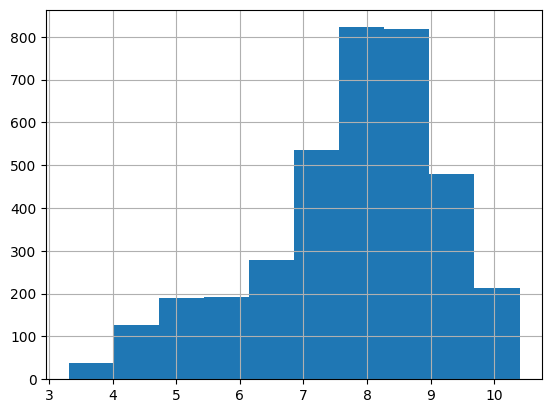

In [21]:
df["IC50_numeric"] = pd.to_numeric(df["IC50 (nM)"], errors='coerce')
df['pIC50'] = -np.log10(df['IC50_numeric'] * 1e-9)

df['pIC50'].hist()

Cleaned Rows: 4055 / 5283


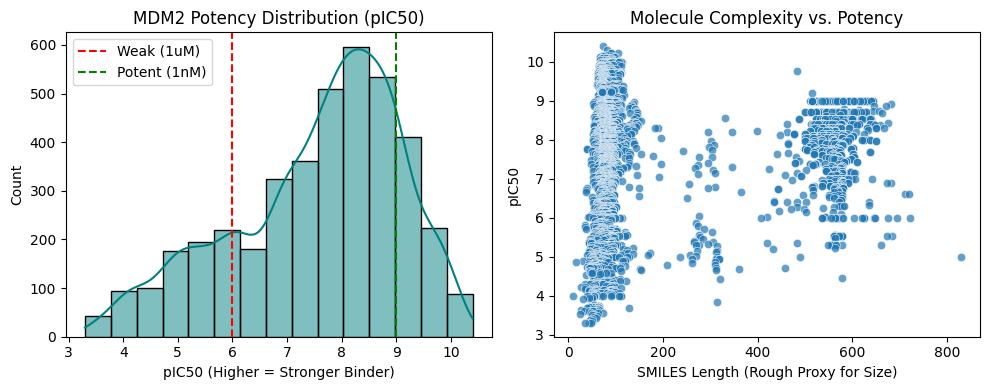

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your sample (Assuming it's already in 'df' from your snippet)
# If reloading: df = pd.read_csv("your_file.tsv", sep='\t', on_bad_lines='skip')

# 2. Clean the IC50 Column (The most important step)
# Regex removes '>' and '<' so we can convert to float
df['IC50_numeric'] = pd.to_numeric(
    df['IC50 (nM)'].astype(str).str.replace(r'[<>]', '', regex=True), 
    errors='coerce'
)

# 3. Create the pIC50 Label (Log-scale potency)
# Formula: -log10(Molar Concentration)
# We limit the max pIC50 to 10.0 to prevent inf values from 0.0 nM
df['pIC50'] = -np.log10(df['IC50_numeric'] * 1e-9)

# Filter out bad conversions (NaNs)
df_clean = df.dropna(subset=['pIC50', 'Ligand SMILES']).copy()

print(f"Cleaned Rows: {len(df_clean)} / {len(df)}")

# 4. EDA Plots
plt.figure(figsize=(10, 4))

# Plot A: The Potency Distribution
plt.subplot(1, 2, 1)
sns.histplot(df_clean['pIC50'], bins=15, kde=True, color='teal')
plt.title('MDM2 Potency Distribution (pIC50)')
plt.xlabel('pIC50 (Higher = Stronger Binder)')
plt.axvline(x=6.0, color='r', linestyle='--', label='Weak (1uM)')
plt.axvline(x=9.0, color='g', linestyle='--', label='Potent (1nM)')
plt.legend()

# Plot B: Molecule Size vs Potency (Sanity Check)
# Longer SMILES usually means bigger molecule. 
# Does bigger = better binder? (Often yes for MDM2 inhibitors)
df_clean['smiles_len'] = df_clean['Ligand SMILES'].str.len()
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clean, x='smiles_len', y='pIC50', alpha=0.7)
plt.title('Molecule Complexity vs. Potency')
plt.xlabel('SMILES Length (Rough Proxy for Size)')

plt.tight_layout()
plt.show()

In [23]:
df["Ligand SMILES"]

0       COc1cc(ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@@...
1       CC[C@@H](CS(=O)(=O)C(C)(C)C)N1[C@@H]([C@H](C[C...
2       CC(C)[C@@H](CS(=O)(=O)C(C)C)N1[C@@H]([C@H](C[C...
3       COc1ccc(CO)cc1-c1nc2C(=O)N([C@H](c2n1C(C)C)c1c...
4       CC(C)[C@@H](CS(=O)(=O)C(C)C)N1[C@@H]([C@H](C[C...
                              ...                        
5278       COc1ccc(NC(C(=O)c2ccc(Cl)cc2)c2ccc(F)cc2Cl)cc1
5279    Nc1cc(cnc1N1CCN(CC1c1ccc(Cl)cc1)C(=O)CC(O)=O)C...
5280      Nc1cc(Cl)cnc1N1CCN(CC1c1ccc(Cl)cc1)C(=O)CC(O)=O
5281    Fc1ccc(cc1)-c1ncn(Cc2ccc(Cl)cc2)c1-c1c([nH]c2c...
5282    Nc1cc(ccc1N1CCN(CC1c1ccc(Cl)cc1)C(=O)CC(O)=O)C...
Name: Ligand SMILES, Length: 5283, dtype: object

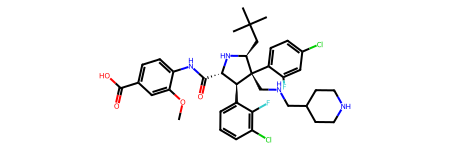

In [24]:
from rdkit import Chem

mol = Chem.MolFromSmiles(df["Ligand SMILES"].iloc[0])
mol


In [25]:
allowed_atoms = [6, 7, 8, 9, 16, 17, 35, 53] # C, N, O, F, P, S, Cl, Br, I
node_feats = []
for atom in mol.GetAtoms():
    an = atom.GetAtomicNum()
    if an in allowed_atoms:
        node_feats.append(allowed_atoms.index(an))
    else:
        node_feats.append(len(allowed_atoms))

x = torch.tensor(node_feats, dtype=torch.long)
print(x.shape)
print(x.unsqueeze(1).shape)

x


torch.Size([49])
torch.Size([49, 1])


tensor([0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 3, 0, 0, 0, 0, 5, 0, 0, 3, 0, 2,
        2])

In [26]:
for bond in mol.GetBonds():
    print(bond.GetBondType())


SINGLE
SINGLE
AROMATIC
AROMATIC
AROMATIC
AROMATIC
AROMATIC
SINGLE
SINGLE
DOUBLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
AROMATIC
AROMATIC
AROMATIC
AROMATIC
SINGLE
AROMATIC
SINGLE
SINGLE
AROMATIC
AROMATIC
AROMATIC
SINGLE
AROMATIC
AROMATIC
SINGLE
SINGLE
SINGLE
DOUBLE
AROMATIC
SINGLE
AROMATIC
AROMATIC
SINGLE


In [27]:
edge_index[1].max()

tensor(97)

In [28]:
row_idx, col_idx = [], []
for bond in mol.GetBonds():
    start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
    row_idx.append(start)
    col_idx.append(end)

edge_index = torch.tensor([row_idx, col_idx], dtype=torch.long)
edge_index.t()

tensor([[ 0,  1],
        [ 1,  2],
        [ 2,  3],
        [ 3,  4],
        [ 4,  5],
        [ 5,  6],
        [ 6,  7],
        [ 7,  8],
        [ 8,  9],
        [ 9, 10],
        [ 9, 11],
        [11, 12],
        [12, 13],
        [13, 14],
        [14, 15],
        [15, 16],
        [15, 17],
        [15, 18],
        [13, 19],
        [19, 20],
        [20, 21],
        [21, 22],
        [22, 23],
        [23, 24],
        [24, 25],
        [25, 26],
        [26, 27],
        [27, 28],
        [19, 29],
        [29, 30],
        [30, 31],
        [31, 32],
        [32, 33],
        [33, 34],
        [34, 35],
        [34, 36],
        [36, 37],
        [19, 38],
        [38, 39],
        [39, 40],
        [40, 41],
        [41, 42],
        [41, 43],
        [43, 44],
        [44, 45],
        [ 4, 46],
        [46, 47],
        [46, 48],
        [ 7,  2],
        [29, 11],
        [36, 30],
        [44, 38],
        [28, 23]])

In [29]:
mol_data = SmallMoleculeFeaturizer(root = os.path.join(ROOT, "data", "MDM2_Breaker"), file_path = mol_file)
mol_data[0]

Data(x=[38, 1], edge_index=[2, 84], y=[1], dtype=torch.float32)

In [30]:
mol_data.data

/var/folders/wt/5vc39b651nn6m5wm29j25dk80000gn/T/ipykernel_10709/1718647821.py:1: UserWarning:

It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.



Data(x=[165537, 1], edge_index=[2, 365144], y=[4037], dtype=[4037])

In [31]:
mol_data[0].x.squeeze()

print(mol_data[0].x.shape)
molecule_embedding = torch.nn.Embedding(8, 128)
molecule_embedding(mol_data[0].x.squeeze()).shape

torch.Size([38, 1])


torch.Size([38, 128])

In [32]:
print(mol_data.x.min(), mol_data.x.max())


tensor(0) tensor(8)


In [33]:
mol_data.slices

{'x': tensor([     0,     38,     80,  ..., 165471, 165508, 165537]),
 'edge_index': tensor([     0,     84,    176,  ..., 365000, 365080, 365144]),
 'y': tensor([   0,    1,    2,  ..., 4035, 4036, 4037]),
 'dtype': tensor([   0,    1,    2,  ..., 4035, 4036, 4037])}

In [34]:
print(mol_data[0].x.shape)
print(mol_data[0].edge_index.shape)
print(mol_data[0].y.shape)


torch.Size([38, 1])
torch.Size([2, 84])
torch.Size([1])


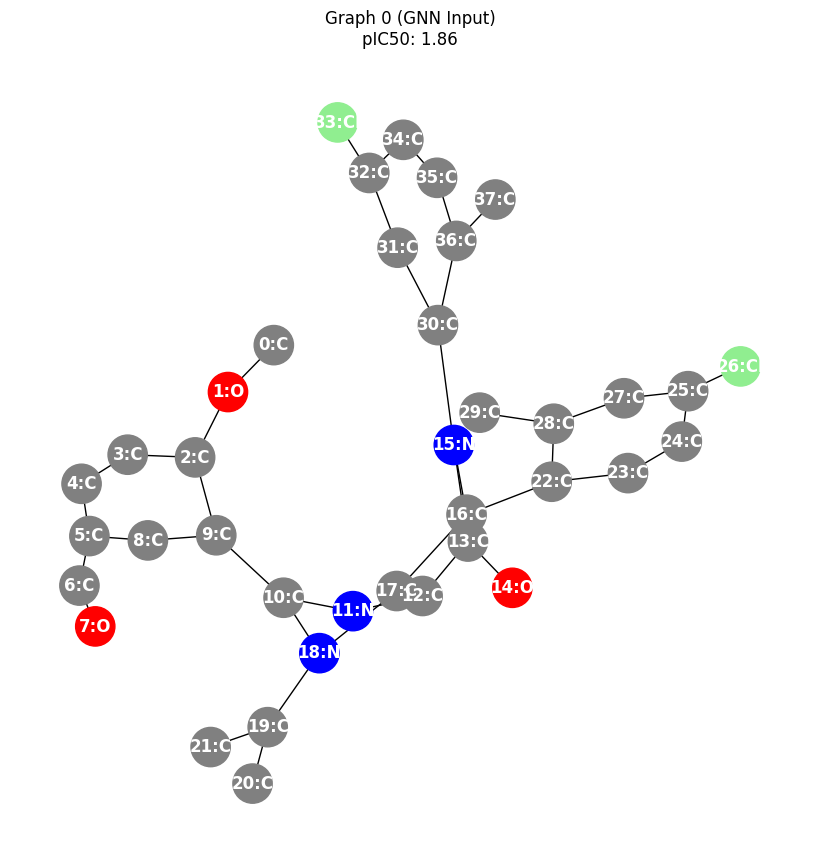

In [35]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def visualize_graph(data, title="Molecule Graph"):
    # 1. Convert PyG Data to NetworkX
    # to_undirected ensures we don't draw two arrows for every bond
    G = to_networkx(data, to_undirected=True)
    
    # 2. Map the "Node Features" back to Element Names
    # Your allowed_atoms list from the featurizer:
    atom_map = {0: 'C', 1: 'N', 2: 'O', 3: 'F', 4: 'S', 5: 'Cl', 6: 'Br', 7: 'I', 8: '?'}
    
    # Create labels and colors for the plot
    labels = {}
    node_colors = []
    
    for node_idx in G.nodes():
        # Get the feature index from the tensor
        # data.x[node_idx] is a tensor like [0], we need the integer 0
        feat_idx = data.x[node_idx].item()
        
        element = atom_map.get(feat_idx, '?')
        labels[node_idx] = f"{node_idx}:{element}" # Format: "Index:Element"
        
        # Color logic (CPK-ish coloring)
        if element == 'C': node_colors.append('gray')
        elif element == 'N': node_colors.append('blue')
        elif element == 'O': node_colors.append('red')
        elif element == 'S': node_colors.append('yellow')
        elif element == 'Cl': node_colors.append('lightgreen')
        else: node_colors.append('orange')

    # 3. Draw it
    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(G, seed=42) # Force-directed layout
    
    nx.draw(G, pos, 
            with_labels=True, 
            labels=labels, 
            node_color=node_colors, 
            node_size=800, 
            font_color='white',
            font_weight='bold',
            edge_color='black')
    
    plt.title(f"{title}\npIC50: {data.y.item():.2f}")
    plt.show()

# --- Run it on the first graph ---
visualize_graph(mol_data[0], title="Graph 0 (GNN Input)")

## Modeling

In [36]:
import pytorch_lightning as pl
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from mdm2_breaker.models import GraphSiameseNetwork

class SarcomaScoutSystem(pl.LightningModule):
    def __init__(self, protein_graph: Data, lr: float = 0.0001):
        """
        Args:
            protein_graph (Data): The static graph of the MDM2 pocket.
            lr (float): Learning rate.
        """
        super().__init__()
        self.save_hyperparameters(ignore=['protein_graph'])
        
        # 1. Initialize the Siamese Network
        self.model = GraphSiameseNetwork(
            protein_in_channels=20,     # One-Hot Amino Acids
            molecule_in_channels=9,     # Atom Indices (0-8)
            out_channels=128,
            molecule_embedding_dim=64
        )
        
        # 2. Store the Protein Graph as a "Buffer"
        # This is the Lightning Magic. By registering these as buffers, 
        # Lightning moves them to the GPU automatically when you start training.
        self.register_buffer('protein_x', protein_graph.x)
        self.register_buffer('protein_edge_index', protein_graph.edge_index)
        # Create a dummy batch vector [0, 0, 0...] for the single protein
        batch_vec = torch.zeros(protein_graph.x.size(0), dtype=torch.long)
        self.register_buffer('protein_batch', batch_vec)
        
        self.lr = lr

    def get_protein_graph(self):
        """Reconstructs the Data object from the GPU buffers."""
        return Data(
            x=self.protein_x, 
            edge_index=self.protein_edge_index, 
            batch=self.protein_batch
        )

    def forward(self, protein_data, molecule_data):
        return self.model(protein_data, molecule_data)

    def training_step(self, batch, batch_idx):
        # 1. Get the Lock (Static Protein)
        protein_data = self.get_protein_graph()
        
        # 2. Get the Keys (Molecule Batch)
        molecule_data = batch
        
        # 3. Predict
        # Output shape: [Batch_Size, 1]
        preds = self(protein_data, molecule_data)
        
        # 4. Loss (MSE for Regression)
        # We squeeze preds to match y: [Batch, 1] -> [Batch]
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)
        
        # 5. Log
        self.log('train_loss', loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def validation_step(self, batch, batch_idx):
        protein_data = self.get_protein_graph()
        molecule_data = batch
        preds = self(protein_data, molecule_data)
        loss = F.mse_loss(preds.squeeze(), molecule_data.y)
        self.log('val_loss', loss, prog_bar=True, batch_size=batch.num_graphs)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        
        # Scheduler: "If val_loss stops dropping for 5 epochs, cut LR by factor of 0.5"
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=0.5, 
            patience=3,
            # verbose=True
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss", # Watch this metric
                "interval": "epoch",
                "frequency": 1,
            },
        }


In [37]:
from torch_geometric.loader import DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor

# --- 1. Prepare Data ---
# Load the Full Dataset (from Week 1)
full_dataset = mol_data.shuffle()

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset = full_dataset[:train_size]
val_dataset = full_dataset[train_size:train_size + val_size]
test_dataset = full_dataset[train_size + val_size:]

# Create Loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=7, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=7, persistent_workers=True)


# INSPECTION BLOCK
batch = next(iter(train_loader))

# Get the Protein Graph (from your ProteinFeaturizer)
protein_graph = protein.get_graph()

# --- 2. Initialize System ---
sarcoma_system = SarcomaScoutSystem(protein_graph=protein_graph)


print(f"Molecule Features (First 5): \n{batch.x[:5].flatten()}")
print(f"Edge Index Shape: {batch.edge_index.shape}")
print(f"Target (y): {batch.y[:5]}")

# Valid Checks
assert batch.x.max() < 9, "Feature indices out of range for Embedding(9)"
assert batch.edge_index.max() < batch.x.size(0), "Edge index points to non-existent node"
assert batch.y.std() > 0, "Targets are all identical (variance = 0)"

print("✅ Data looks valid. Proceed with training fixes.")

Molecule Features (First 5): 
tensor([0, 1, 0, 0, 1])
Edge Index Shape: torch.Size([2, 5898])
Target (y): tensor([ 1.0492,  0.5611,  1.4777, -1.9818, -0.4127])
✅ Data looks valid. Proceed with training fixes.


In [38]:
# --- 3. Define Callbacks ---
# Checkpoint: Save the model with the lowest Validation Loss
checkpoint_cb = ModelCheckpoint(
    dirpath='checkpoints/',
    filename='sarcoma-model-{epoch:02d}-{val_loss:.2f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1
)

# Early Stopping: Stop if val_loss doesn't improve for 10 epochs
early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='min'
)

lr_monitor = LearningRateMonitor(logging_interval='epoch')

# --- 4. Train! ---
trainer = pl.Trainer(
    max_epochs=50,
    accelerator='cpu', # Automatically finds your GPU (or M1 Metal)
    devices=1,
    callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
    log_every_n_steps=10
)
# trainer = pl.Trainer(
#     overfit_batches=1,      # <--- The Truth Serum. Uses only 1 batch of data.
#     max_epochs=100,         # Give it time to memorize
#     check_val_every_n_epoch=1,
#     gradient_clip_val=1.0,
#     accelerator='cpu',      # Safer for debugging
#     enable_progress_bar=True
# )
import copy
initial_weights = copy.deepcopy(sarcoma_system.model.state_dict())
print("Starting Training...")
# trainer.fit(sarcoma_system, train_loader, val_loader)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores


Starting Training...


/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/dantrainer/miniconda3/envs/cancer_env/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [39]:
for key in initial_weights:
    diff = (initial_weights[key] - sarcoma_system.model.state_dict()[key]).abs().sum()
    if diff > 0:
        print(f"{key} changed by {diff:.4f}")

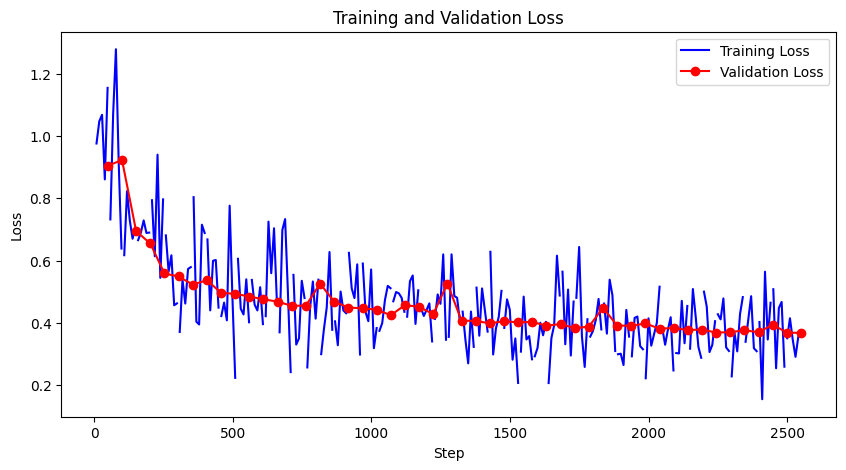

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
# read the training logs
df = pd.read_csv("lightning_logs/version_37/metrics.csv")
fix, ax = plt.subplots(figsize=(10, 5))
df.plot(x="step", y="train_loss", title="Training Loss", ax=ax, label="Training Loss", color="blue", legend=True, style="-",)
df.dropna(subset=["val_loss"]).plot(x="step", y="val_loss", title="Validation Loss", ax=ax, label="Validation Loss", color="red", legend=True, style="-o")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
plt.show()


In [41]:
import torch

# 1. Load the raw checkpoint
checkpoint = torch.load("checkpoints/sarcoma-model-epoch=49-val_loss=0.37.ckpt")
state_dict = checkpoint['state_dict']

# 2. Fix the keys (Remove "model." prefix)
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith("model."):
        # Strip the first 6 characters ("model.")
        new_key = key[6:]  
        new_state_dict[new_key] = value

# 3. Initialize your raw model
model = GraphSiameseNetwork(
    protein_in_channels=20,
    molecule_in_channels=9,
    out_channels=128,
    molecule_embedding_dim=64
)

# 4. Load the cleaned weights
model.load_state_dict(new_state_dict)
model.eval()

GraphSiameseNetwork(
  (protein_encoder): GCNEncoder(
    (conv1): GCNConv(20, 1024)
    (conv2): GCNConv(1024, 512)
    (conv3): GCNConv(512, 256)
    (conv4): GCNConv(256, 128)
  )
  (molecule_embedding): Embedding(9, 64)
  (molecule_encoder): GCNEncoder(
    (conv1): GCNConv(64, 1024)
    (conv2): GCNConv(1024, 512)
    (conv3): GCNConv(512, 256)
    (conv4): GCNConv(256, 128)
  )
  (attention_pool): AttentionalAggregation(gate_nn=Linear(in_features=128, out_features=1, bias=True), nn=None)
  (mlp): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [ ]:
x

DataBatch(x=[1169, 1], edge_index=[2, 2606], y=[29], dtype=[29], batch=[1169], ptr=[30])

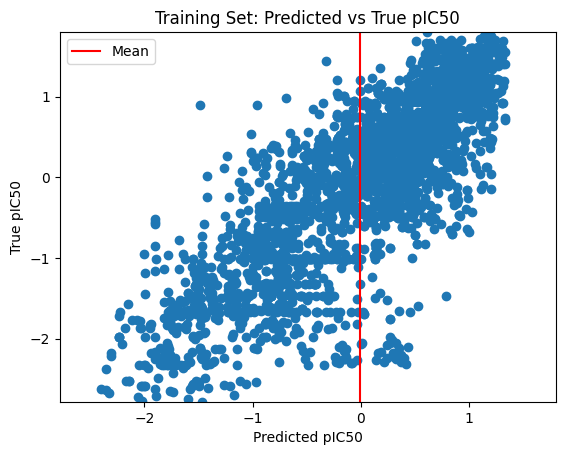

In [75]:
y_pred_train = []
y_true_train = []
x_values_train = []
for x in train_loader:
    x_values_train.append(x.x.detach().cpu().numpy())
    y_pred_train.append(model(protein_graph, x).detach().cpu().numpy())
    y_true_train.append(x.y.detach().cpu().numpy())

y_pred_train = np.concatenate(y_pred_train)
y_true_train = np.concatenate(y_true_train)
# x_values_train = np.concatenate(x_values_train)

plt.scatter(y_pred_train, y_true_train)
plt.plot([y_true_train.mean(), y_true_train.mean()], [y_true_train.min(), y_true_train.max()], color="red", label="Mean")
plt.xlabel("Predicted pIC50")
plt.ylabel("True pIC50")
plt.title("Training Set: Predicted vs True pIC50")
plt.xlim(y_true_train.min(), y_true_train.max())
plt.ylim(y_true_train.min(), y_true_train.max())
plt.legend()
plt.show()

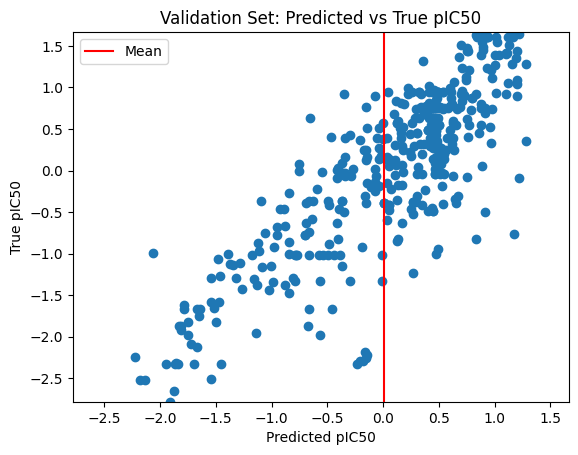

In [57]:
y_pred_val = []
y_true_val = []
x_values_val = []
for x in val_loader:
    x_values_val.append(x.x.detach().cpu().numpy())
    y_pred_val.append(model(protein_graph, x).detach().cpu().numpy())
    y_true_val.append(x.y.detach().cpu().numpy())

y_pred_val = np.concatenate(y_pred_val)
y_true_val = np.concatenate(y_true_val)
x_values_val = np.concatenate(x_values_val)

plt.scatter(y_pred_val, y_true_val)
plt.plot([y_true_val.mean(), y_true_val.mean()], [y_true_val.min(), y_true_val.max()], color="red", label="Mean")
plt.xlabel("Predicted pIC50")
plt.ylabel("True pIC50")
plt.title("Validation Set: Predicted vs True pIC50")
plt.xlim(y_true_val.min(), y_true_val.max())
plt.ylim(y_true_val.min(), y_true_val.max())
plt.legend()
plt.show()

In [71]:
np.expand_dims(y_true_train, axis=1).shape

(3229, 1)

In [69]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(x_values_train, np.expand_dims(y_true_train, axis=1))

y_pred_train_xgb = xgb_model.predict(x_values_train)

plt.scatter(y_pred_train_xgb, y_true_train)
plt.plot([y_true_train.mean(), y_true_train.mean()], [y_true_train.min(), y_true_train.max()], color="red", label="Mean")
plt.xlabel("Predicted pIC50")
plt.ylabel("True pIC50")
plt.title("Training Set: Predicted vs True pIC50")

XGBoostError: [20:38:15] /Users/runner/work/xgboost/xgboost/src/data/data.cc:542: Check failed: this->labels.Size() % this->num_row_ == 0 (3229 vs. 0) : Incorrect size for labels: (3229,1) v.s. 132939
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x000000032758d9e0 dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x00000003276f1860 xgboost::MetaInfo::SetInfoFromHost(xgboost::Context const*, xgboost::StringView, xgboost::Json) + 2580
  [bt] (2) 3   libxgboost.dylib                    0x00000003276f0cc0 xgboost::MetaInfo::SetInfo(xgboost::Context const&, xgboost::StringView, xgboost::StringView) + 464
  [bt] (3) 4   libxgboost.dylib                    0x00000003275a528c XGDMatrixSetInfoFromInterface + 228
  [bt] (4) 5   libffi.8.dylib                      0x0000000102d3404c ffi_call_SYSV + 76
  [bt] (5) 6   libffi.8.dylib                      0x0000000102d31834 ffi_call_int + 1404
  [bt] (6) 7   _ctypes.cpython-311-darwi